In [1]:
%pip install torch transformers "trl>=0.11" peft accelerate matplotlib datasets -q


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: /Users/unmeshmali/Downloads/Unmesh/deepmlhub/projects/llm-retard-lab/courses/deeplearning_posttraining/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Loading data and split

In [1]:
from datasets import load_dataset, disable_progress_bar
import json

/Users/unmeshmali/Downloads/Unmesh/deepmlhub/projects/llm-retard-lab/courses/deeplearning_posttraining/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
disable_progress_bar()

In [3]:
ds = load_dataset(
    "json",
    data_files = "../data/01_cold_start_cot_sft/data.jsonl",
    split="train",
)

In [4]:
ds

Dataset({
    features: ['spec', 'prompt', 'response'],
    num_rows: 496
})

In [5]:
df = ds.to_pandas()
df.head()

,spec,prompt,response
0,"{'topic': 'damaged-item', 'tone': 'confused', ...","Hi, I just opened my order of running sneakers...",<thinking>The customer is reporting a damaged ...
1,"{'topic': 'damaged-item', 'tone': 'urgent', 'i...",Customer: I just opened the box and my wireles...,<thinking>I need to review the policy: 30-day ...
2,"{'topic': 'cancel-order', 'tone': 'polite', 'i...","Customer: Hello, I'd like to cancel my order f...",<thinking>The customer wants to return an elec...
3,"{'topic': 'return-out-of-window', 'tone': 'pol...","Hi, I’d like to return the protein powder I or...",<thinking>\n- The customer wants to return a p...
4,"{'topic': 'return-in-window', 'tone': 'frustra...",I bought an electric toothbrush 22 days ago an...,<thinking>The customer is frustrated and claim...


In [6]:
split = ds.train_test_split(test_size=25, seed=42)

train_ds, val_ds = split["train"], split["test"]
print(f"train: {len(train_ds)} | val (loss curve): {len(val_ds)}")

train: 471 | val (loss curve): 25


# Building messages

###
The raw data has no structure: each row is just prompt and response — two flat strings. The model doesn't know "this part was the customer, that part was the agent." Its training made it expect a chat template like:
<|im_start|>user
I bought a serum 7 days ago...<|im_end|>
<|im_start|>assistant
Sure, here's your return window...<|im_end|>
The messages column is the structured source that TRL tokenizes from:
[{"role": "user", "content": prompt},
 {"role": "assistant", "content": response}]
###

In [7]:
def to_message(example): 
    return {
        "messages":  [
            {"role": "user", "content": example["prompt"]}, 
            {"role": "assistant", "content": example["response"]}, 
        ]
    }

In [8]:
train_ds = train_ds.map(to_message)
val_ds = val_ds.map(to_message)

In [9]:
## Quick sanity check on the above data 
train_df = train_ds.to_pandas()
val_df = val_ds.to_pandas()

for name, df in [("train", train_df), ("val", val_df)]:
    df["prompt_words"] = df["prompt"].str.split().str.len()
    df["resp_words"] = df["response"].str.split().str.len()
    df["total_words"] = df["prompt_words"] + df["resp_words"]
    print(f"--- {name} ({len(df)}) ---")
    print(df["total_words"].describe())
    print(f"p99 total_words: {df['total_words'].quantile(0.99):.0f}")
    print(f"> 1024 words: {(df['total_words'] > 1024).sum()} rows\n")

--- train (471) ---
count    471.000000
mean     296.477707
std       67.648804
min      151.000000
25%      252.000000
50%      283.000000
75%      332.000000
max      609.000000
Name: total_words, dtype: float64
p99 total_words: 511
> 1024 words: 0 rows

--- val (25) ---
count     25.000000
mean     295.240000
std       64.247101
min      215.000000
25%      250.000000
50%      282.000000
75%      325.000000
max      506.000000
Name: total_words, dtype: float64
p99 total_words: 485
> 1024 words: 0 rows



# Model + LoRA

In [10]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig

In [19]:
MODEL_NAME = "Qwen/Qwen2.5-0.5B" # using this to test in the notebook, will swap it for a larger model on the pod

In [20]:
"""
MPS = Metal Performance Shaders — Apple's API that lets PyTorch run tensor math on the Mac's GPU (the silicon inside the M1/M2/etc. chip).
Where it sits in the stack:
- CUDA = NVIDIA's GPU computing API (the ML industry standard)
- MPS = Apple's equivalent for its own GPUs — PyTorch's backend to talk to Apple Silicon
So the same line of code runs on either:
device = "mps" if torch.backends.mps.is_available() else "cpu"
- Mac with Apple Silicon → "mps" → uses the GPU
- Mac without / old Intel → "cpu" → slow fallback
"""

device = "mps" if torch.backends.mps.is_available() else "cpu"

In [24]:
"""
loads the model from Hugging Face into memory and moves it onto the compute device (MPS/CPU). Breaking it down left to right:
AutoModelForCausalLM — the class responsible for next-token prediction. The Auto part means it reads the model's own config file and picks the right architecture class for it automatically (Qwen2.5 → Qwen2ForCausalLM). One import, any model family.
.from_pretrained(MODEL_NAME) — downloads the weights from the HF Hub (if not cached), reads the config, and builds the full model object. MODEL_NAME = "Qwen/Qwen2.5-0.5B" — repo owner + model name.
torch_dtype=torch.float16 — load the weights as fp16 (half precision) instead of fp32. On your Mac this roughly halves memory usage. Fine for a dry-run; a real trick on GPUs where fp16/bf16 is the norm.
.to(device) — move the tensor computation to where the math happens. device = "mps" if available (Apple Silicon GPU), else "cpu". Without this, everything stays on CPU and the dry-run is very slow.
"""

model = AutoModelForCausalLM.from_pretrained(MODEL_NME, torch_dtype=torch.float16).to(device)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 2760.27it/s]


In [21]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NME)

In [22]:
tokenizer.pad_token = tokenizer.eos_token

In [23]:
lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05, 
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], 
    task_type="CAUSAL_LM"
)

# Trainer

In [24]:
from trl import SFTTrainer, SFTConfig

In [33]:
sft_config = SFTConfig(
    output_dir="../models/adapter_qwen_cot",
    max_length=1024,
    packing=False,
    completion_only_loss=True,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    num_train_epochs=3,
    logging_steps=10,
    max_steps=5,              # dry-run only — remove for the real run
    eval_strategy="steps",
    eval_steps=2,
    save_strategy="no",
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [39]:
## daataset has both a prompt and a message column.removing the raw columns

train_ds = train_ds.map(to_message).remove_columns(["prompt", "response"])
val_ds = val_ds.map(to_message).remove_columns(["prompt", "response"])

In [40]:
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer, 
    args=sft_config, 
    train_dataset=train_ds.select(range(20)), #dry-run on 20 samples
    eval_dataset=val_ds.select(range(5)), 
    peft_config=lora_config
)

/Users/unmeshmali/Downloads/Unmesh/deepmlhub/projects/llm-retard-lab/courses/deeplearning_posttraining/.venv/lib/python3.10/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/Users/unmeshmali/Downloads/Unmesh/deepmlhub/projects/llm-retard-lab/courses/deeplearning_posttraining/.venv/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [41]:
trainer.train()
trainer.save_model("../models/adapter_qwen_cot")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/Users/unmeshmali/Downloads/Unmesh/deepmlhub/projects/llm-retard-lab/courses/deeplearning_posttraining/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
2,No log,2.838727,2.842478,8127.000000,0.409245
4,No log,nan,nan,16254.000000,0.002120
5,No log,nan,nan,22858.000000,0.002120


# Reading the results above: 

- Step 2 looks healthy: val loss 2.84, token accuracy 0.41 → loss dropped from init (~3.x), the loop, LoRA, and gradients all work.
- Steps 4–5 = NaN → the weights exploded (accuracy collapsing to 0.002 = model outputting garbage). Classic divergence.
Diagnosis: almost certainly fp16 on MPS. Apple's mps backend has unreliable fp16 autocast — it silently overflows intermediate gradients to inf/NaN, especially with AdamW. Your code isn't wrong; the hardware precision is.

In [25]:
print(MODEL_NAME)

Qwen/Qwen2.5-0.5B


In [26]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,   # fp32 for the MPS dry run (no fp16 anywhere)
).to(device)

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 374.94it/s]


In [27]:
sft_config = SFTConfig(
    output_dir="../models/adapter_qwen_cot",
    max_length=1024,
    packing=False,
    completion_only_loss=True,
    fp16=False,
    bf16=False,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    num_train_epochs=3,
    max_steps=5,
    eval_strategy="steps",
    eval_steps=2,
    save_strategy="no",
    logging_steps=1,
    report_to="none",
)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [29]:
## daataset has both a prompt and a message column.removing the raw columns

train_ds = train_ds.map(to_message).remove_columns(["prompt", "response"])
val_ds = val_ds.map(to_message).remove_columns(["prompt", "response"])

In [30]:
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=sft_config,
    train_dataset=train_ds.select(range(20)),  # dry-run on 20 samples
    eval_dataset=val_ds.select(range(5)),
    peft_config=lora_config,
)

/Users/unmeshmali/Downloads/Unmesh/deepmlhub/projects/llm-retard-lab/courses/deeplearning_posttraining/.venv/lib/python3.10/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/Users/unmeshmali/Downloads/Unmesh/deepmlhub/projects/llm-retard-lab/courses/deeplearning_posttraining/.venv/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [31]:
trainer.train()
trainer.save_model("../models/adapter_qwen_cot_2")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.
/Users/unmeshmali/Downloads/Unmesh/deepmlhub/projects/llm-retard-lab/courses/deeplearning_posttraining/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
2,2.761037,2.546201,2.364442,8127.000000,0.443643
4,2.394357,2.432665,2.330373,16254.000000,0.467995
5,2.373558,2.420700,2.323891,22858.000000,0.469771


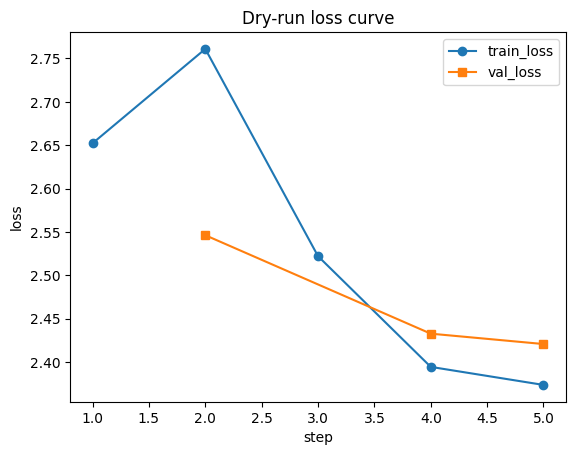

In [33]:
import matplotlib.pyplot as plt

log = trainer.state.log_history
train = [x for x in log if "loss" in x]
val   = [x for x in log if "eval_loss" in x]

plt.plot([x["step"] for x in train], [x["loss"] for x in train], "o-", label="train_loss")
plt.plot([x["step"] for x in val],   [x["eval_loss"] for x in val], "s-", label="val_loss")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("Dry-run loss curve")
plt.show()